In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb
tf.keras.utils.set_random_seed(42)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data = pd.read_csv(r"/content/aapl_2014_2023-more-columns.csv")

In [4]:
data.describe()

,open,high,low,close,volume,rsi_7,macd,bollinger
count,2516.000000,2516.000000,2516.000000,2516.000000,2.516000e+03,2516.000000,2516.000000,2516.000000
mean,77.856671,78.704468,77.060193,77.920721,1.366662e+08,55.829312,0.477411,77.261412
std,56.171865,56.808974,55.581734,56.226768,8.403551e+07,17.720405,1.820108,55.795529
min,17.684999,17.911785,17.626785,17.849285,2.404830e+07,7.771611,-6.673117,18.645339
25%,29.740001,29.976250,29.554375,29.803750,8.138358e+07,42.223776,-0.208277,29.462344
50%,47.963749,48.534999,47.743749,48.107500,1.121606e+08,56.567948,0.344944,47.652813
75%,134.792496,135.995002,133.325004,134.562497,1.668892e+08,70.072551,1.180283,133.377500
max,198.020004,199.619995,197.000000,198.110001,1.065523e+09,94.046150,7.511570,194.308501


In [5]:
data.head(5)

,date,open,high,low,close,volume,rsi_7,macd,bollinger
0,2014-01-02,19.845715,19.893929,19.715000,19.754642,234684800,44.149614,0.194637,19.979268
1,2014-01-03,19.745001,19.775000,19.301071,19.320715,392467600,33.094332,0.132887,19.936375
2,2014-01-06,19.194643,19.528570,19.057142,19.426071,412610800,37.525661,0.091398,19.893571
3,2014-01-07,19.440001,19.498571,19.211430,19.287144,317209200,34.055624,0.046768,19.857893
4,2014-01-08,19.243214,19.484285,19.238930,19.409286,258529600,39.768497,0.021012,19.816875


In [6]:
data_clean = data.copy()

In [7]:
duplicate_count = data_clean.duplicated().sum()
print(duplicate_count)

0


In [8]:
missing_values = data_clean.isnull().sum()
print(missing_values)

date         0
open         0
high         0
low          0
close        0
volume       0
rsi_7        0
macd         0
bollinger    0
dtype: int64


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

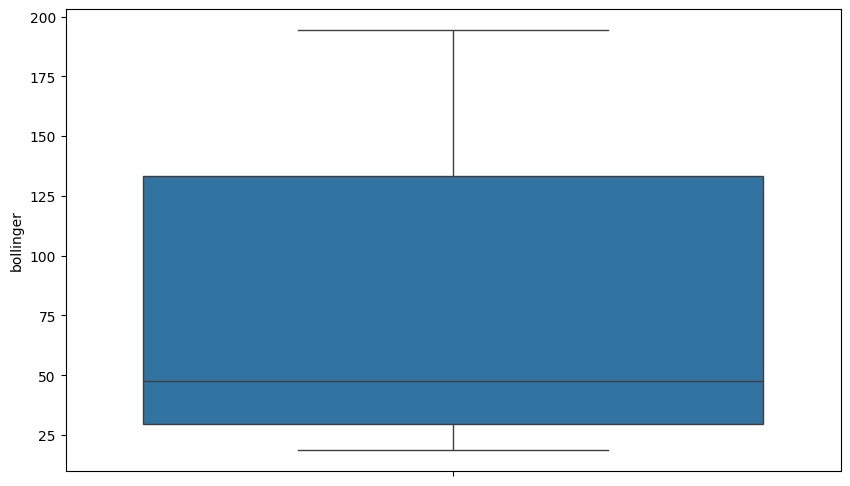

In [9]:
plt.figure(figsize=(10,6))
sb.boxplot(data_clean['bollinger'])
plt

In [10]:
data_clean['date'] = pd.to_datetime(data_clean['date'], format='%Y-%m-%d')
data_clean = data_clean.sort_values(by='date')
split_point = int(len(data_clean) * 0.85
                  )
data_train = data_clean.iloc[:split_point]
data_test = data_clean.iloc[split_point:]
print(split_point)
print(data_train.shape)
print(data_test.shape)

2138
(2138, 9)
(378, 9)


# training raw data

In [11]:
# Create X_train_features_raw by dropping only 'date' from data_train
X_train_features_raw = data_train.drop(columns=['date']).copy()

# Define y_train_target_raw (next day's close price)
y_train_target_raw = data_train['close'].shift(-1)

# Align X and y by dropping the last row from both as y_train_target_raw will have a NaN
X_train_features_raw = X_train_features_raw.iloc[:-1]
y_train_target_raw = y_train_target_raw.iloc[:-1]
print(f"Shape of X_train_features_raw: {X_train_features_raw.shape}")
print(f"Shape of y_train_target_raw: {y_train_target_raw.shape}")
print(X_train_features_raw.columns)



Shape of X_train_features_raw: (2137, 8)
Shape of y_train_target_raw: (2137,)
Index(['open', 'high', 'low', 'close', 'volume', 'rsi_7', 'macd', 'bollinger'], dtype='object')


In [12]:
X_test_features_raw = data_test.drop(columns=['date']).copy()
y_test_target_raw = data_test['close'].shift(-1)
X_test_features_raw = X_test_features_raw.iloc[:-1]
y_test_target_raw = y_test_target_raw.iloc[:-1]
print(f"Shape of X_test_features_raw: {X_test_features_raw.shape}")
print(f"Shape of y_test_target_raw: {y_test_target_raw.shape}")

Shape of X_test_features_raw: (377, 8)
Shape of y_test_target_raw: (377,)


In [13]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# We need two separate scalers so we can inverse-transform the target later
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit and transform features
X_train_features_raw_scaled = scaler_X.fit_transform(X_train_features_raw)

# Fit and transform target (convert Series to numpy using .values before reshaping)
y_train_target_raw_scaled = scaler_y.fit_transform(y_train_target_raw.values.reshape(-1, 1))


In [14]:
import numpy as np

# Pass the DataFrame directly to avoid the feature names warning
X_test_features_raw_scaled = scaler_X.transform(X_test_features_raw)

# Convert Series to numpy values and reshape before transforming with scaler_y
y_test_target_raw_scaled = scaler_y.transform(y_test_target_raw.values.reshape(-1, 1))


In [15]:
if data['close'][1] == y_train_target_raw[0]:
  print('true')

true


In [16]:
X_train = []
y_train = []
window = 20

for i in range(len(X_train_features_raw_scaled) - window):
    # Using the scaled versions
    X_train.append(X_train_features_raw_scaled[i:i+window])
    y_train.append(y_train_target_raw_scaled[i+window-1])

X_train = np.array(X_train)
y_train = np.array(y_train)

print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')

X_train shape: (2117, 20, 8)
y_train shape: (2117, 1)


In [17]:
X_test = []
y_test = []
for i in range(len(X_test_features_raw_scaled) - window):
    # Using the scaled versions
    X_test.append(X_test_features_raw_scaled[i:i+window])
    y_test.append(y_test_target_raw_scaled[i+window-1])
X_test = np.array(X_test)
y_test = np.array(y_test)
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

X_test shape: (357, 20, 8)
y_test shape: (357, 1)


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

model = Sequential()
model.add(Input(shape=(20, 8))) # Changed from 6 to 8 to match X_train features
model.add(LSTM(units=70 , return_sequences=False))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 70)             │        22,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            71 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,191 (86.68 KB)

 Trainable params: 22,191 (86.68 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, shuffle=False,)

Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0020 - val_loss: 0.0071
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0075 - val_loss: 6.5918e-04
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 3.5594e-04 - val_loss: 9.3759e-04
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 4.0139e-04 - val_loss: 7.9072e-04
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 2.9918e-04 - val_loss: 7.0379e-04
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 4.4516e-04 - val_loss: 6.5371e-04
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 4.6902e-04 - val_loss: 5.3563e-04
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.4025e-04 - val_loss: 5.8261e-04
Epoch 9/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.8792e-04 - val_loss: 5.0585e-04
Epoch 10/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.7200e-04 - val_loss: 6.1427e-04
Epoch 11/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.0564e-04 - val_loss

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
predictions = model.predict(X_test)
predictions.shape


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


(357, 1)

In [21]:
predictions = scaler_y.inverse_transform(predictions)
y_test = scaler_y.inverse_transform(y_test)
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'R-squared: {r2}')

Mean Squared Error: 8.46617289019238
Mean Absolute Error: 2.2560672497155103
R-squared: 0.9759796220992597


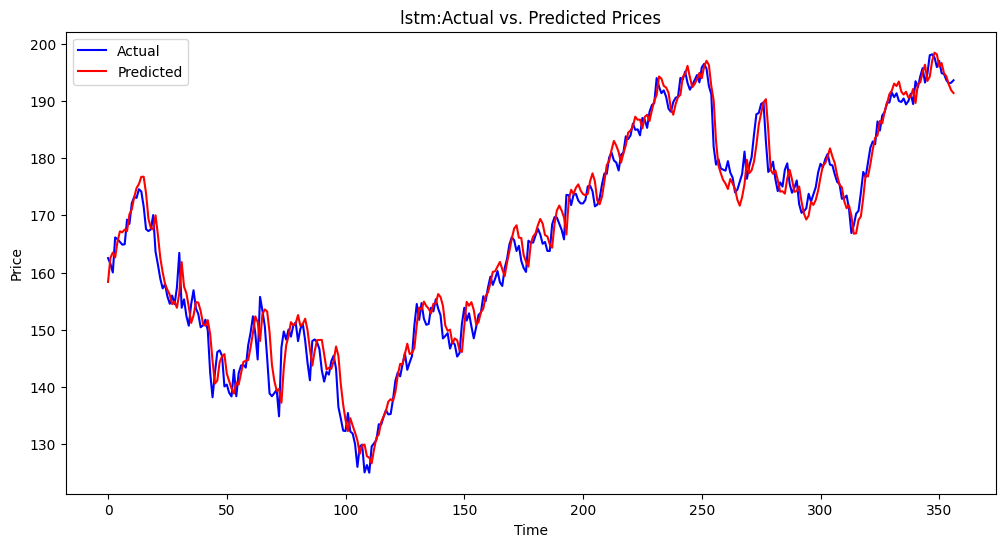

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual', color='blue')
plt.plot(predictions, label='Predicted', color='red')
plt.title('lstm:Actual vs. Predicted Prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

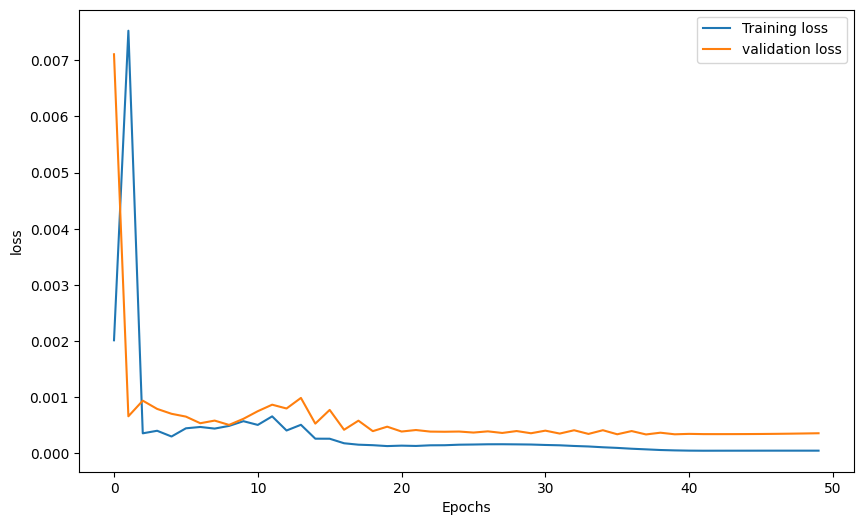

In [23]:
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [24]:
model.save('lstm_stock_predictor.h5')
print("Model saved to /content/drive/MyDrive/lstm_stock_predictor.h5")

Model saved to /content/drive/MyDrive/lstm_stock_predictor.h5
